# Muon² hypothesis test on chord-tight r=64 snapshots

Load per-step (A, B, m_A, v_A, m_B, v_B, u_A, u_B) dumps from
`/mnt/ceph/users/nghosh/lora_snapshots/chord_tight_r64_k3_snapshot_blackwell/`
and visualize the paper-relevant quantities:

- $A, B$ — LoRA factors at the snapshot step (§9 inputs)
- $u_A, u_B$ — Adam-RMS direction (bias-corrected, pre-σmax)
- $M_t$ = raw EMA momentum (paper Eq. 2) = `m_A`
- $\tilde M_t = M_t \oslash (\sqrt{V_t} + \varepsilon)$ = Adam-scaled momentum (paper Eq. 4)
- Spectrum of $M_t$ vs $\tilde M_t$ (paper Fig. 1a/1b)
- Effective rank trajectory (paper Fig. 1c)

Snapshot cadence: step ∈ {0, 50, 200, 500, 1000, 2000, 4000}. Each snapshot dir
has `adapter/`, `optimizer.pt`, `meta.json`.

In [6]:
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

SNAP_ROOT = Path('/mnt/ceph/users/nghosh/lora_snapshots/chord_tight_r64_k3_snapshot_blackwell/task_0')
STEPS = sorted([int(p.name.split('_')[1]) for p in SNAP_ROOT.glob('step_*')])
print('available snapshot steps:', STEPS)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
available snapshot steps: [0, 50, 200, 500, 1000, 2000, 4000]


## Loader

`optimizer.pt` is a dict with keys `pair_state`, `group_state`, `param_groups`,
`state`. `pair_state[i]` is a dict per LoRA pair holding the per-pair tensors
we stashed at snapshot time, plus the standard Adam moments. Tensors are CPU
float32.

In [ ]:
def load_snapshot(step):
    """Load one snapshot. Returns dict with 'pair_state', 'group_state', 'meta'."""
    sd = torch.load(SNAP_ROOT / f'step_{step}' / 'optimizer.pt',
                    map_location='cpu', weights_only=False)
    meta = json.loads((SNAP_ROOT / f'step_{step}' / 'meta.json').read_text())
    return {'pair_state': sd['pair_state'], 'group_state': sd.get('group_state', []),
            'meta': meta}

snap = load_snapshot(2000)
print('# pairs:', len(snap['pair_state']))
print('pair 0 keys:', sorted(snap['pair_state'][0].keys()))
for k in ('A', 'B', 'm_A', 'v_A', 'u_A'):
    t = snap['pair_state'][0][k]
    print(f'  {k:5s} shape={tuple(t.shape)} dtype={t.dtype}')
print('step counter:', snap['pair_state'][0]['step'])

## Pair index → layer name mapping

Pair indices are deterministic given the model + PEFT config, but the names
aren't stored in the snapshot. Recover by instantiating the same model
and calling `collect_lora_pairs_named`. Slow (~30s for OLMo-2-1B); cache the
result for the session.

In [8]:
import sys
sys.path.insert(0, '/mnt/home/nghosh/lora')

from lora_playground.utils import collect_lora_pairs_named
from peft import LoraConfig, get_peft_model
from transformers import AutoModelForCausalLM

def recover_pair_names(lora_r=64):
    base = AutoModelForCausalLM.from_pretrained('allenai/OLMo-2-0425-1B',
                                                torch_dtype=torch.float32)
    cfg = LoraConfig(r=lora_r, lora_alpha=lora_r, target_modules='all-linear',
                     lora_dropout=0.0, init_lora_weights=True)
    model = get_peft_model(base, cfg)
    named = collect_lora_pairs_named(model, adapter_name=None)
    return [n for _, _, n in named]

# Uncomment when you need names. Leave commented for fast iteration.
# PAIR_NAMES = recover_pair_names()
# for i, n in enumerate(PAIR_NAMES[:5]):
#     print(f'  {i:3d}  {n}')

## Compute $M_t$, $\tilde M_t$ for one pair / one step

$M_t$ is `m_A` post-EMA (already in pair_state). $\tilde M_t$ uses the **paper's
convention** (no bias correction):

$$\tilde M_t = M_t \oslash (\sqrt{V_t} + \varepsilon).$$

Our optimizer's stashed `u_A` is the bias-corrected variant
$\hat M_t / (\sqrt{\hat V_t} + \varepsilon)$ where $\hat M_t = M_t/(1-\beta_1^t)$.
Useful as a sanity-check anchor.

In [ ]:
EPS = 1e-8
BETA1, BETA2 = 0.9, 0.999

def Mtilde(pair, side='A', bias_correct=False):
    """Paper's M̃_t (no bc) or our optimizer's u_A / u_B (with bc)."""
    m = pair[f'm_{side}']
    v = pair[f'v_{side}']
    if bias_correct:
        t = pair['step']
        m = m / (1 - BETA1 ** t)
        v = v / (1 - BETA2 ** t)
    return m / (v.sqrt() + EPS)

# Pick one pair to demo.
PAIR = 0
p = snap['pair_state'][PAIR]
M_A = p['m_A']
Mt_A_paper = Mtilde(p, 'A', bias_correct=False)
Mt_A_ours  = Mtilde(p, 'A', bias_correct=True)
u_A = p['u_A']

# Sanity: our stashed u_A should match the bc=True recomputation.
drift = (Mt_A_ours - u_A).abs().max().item()
print(f'max |recompute(bc=True) - u_A| = {drift:.2e}')

# Quick stats.
for name, mat in [('M_t (raw)', M_A),
                  ('M̃_t (paper, no bc)', Mt_A_paper),
                  ('M̃_t (bc, our u_A)', u_A)]:
    s = torch.linalg.svdvals(mat).numpy()
    print(f'{name:28s}  ‖⋅‖_F = {mat.norm().item():9.4f}  '
          f'σ_max = {s[0]:9.4f}  σ_min = {s[-1]:9.4f}  '
          f'eff_rank = {(s.sum()**2 / (s**2).sum()):6.2f}')

## Spectrum of $M_t$ vs $\tilde M_t$ at one step (paper Fig. 1a/1b style)

Frobenius-normalized to remove the global scale factor; the paper's claim is
about the *distribution* of singular values, not their absolute magnitude.

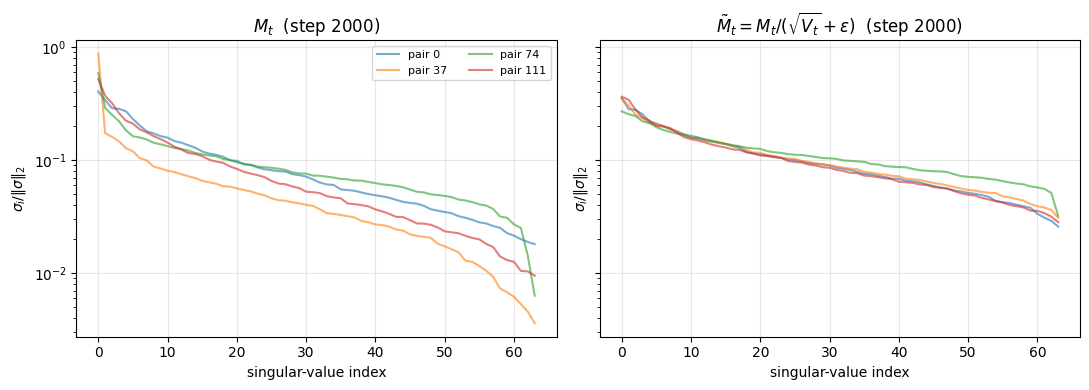

In [10]:
def normalized_sigmas(mat):
    s = torch.linalg.svdvals(mat.float()).numpy()
    return s / np.linalg.norm(s)  # sum(s²)=1 after this

def plot_spectra(step, pair_indices=None, n_pairs_to_plot=4, side='A'):
    snap = load_snapshot(step)
    n_pairs = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_pairs - 1, n_pairs_to_plot, dtype=int)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
    for pi in pair_indices:
        p = snap['pair_state'][int(pi)]
        s_M = normalized_sigmas(p[f'm_{side}'])
        s_Mt = normalized_sigmas(Mtilde(p, side, bias_correct=False))
        axes[0].plot(s_M,  alpha=0.6, label=f'pair {int(pi)}')
        axes[1].plot(s_Mt, alpha=0.6, label=f'pair {int(pi)}')
    axes[0].set_title(f'$M_t$  (step {step})')
    axes[1].set_title(f'$\\tilde M_t = M_t / (\\sqrt{{V_t}} + \\varepsilon)$  (step {step})')
    for ax in axes:
        ax.set_yscale('log')
        ax.set_xlabel('singular-value index')
        ax.set_ylabel('$\\sigma_i / \\|\\sigma\\|_2$')
        ax.grid(True, alpha=0.3)
    axes[0].legend(fontsize=8, ncol=2)
    fig.tight_layout()
    return fig

plot_spectra(2000, n_pairs_to_plot=4, side='A')
plt.show()

## Newton–Schulz polar output spectrum: muon vs muon² (paper Fig. 2 style)

Apply $N_s$ iterations of the Newton–Schulz polar map to the Frobenius-normalized
input, then read off the resulting singular values. The true polar factor has
$\sigma_i = 1$ for all $i$ (dashed line); the closer NS converges to that line
at small $N_s$, the easier the polar approximation.

- **Muon** input: raw momentum $M_t$ (= `m_A`)
- **Muon²** input: Adam-scaled momentum $\tilde M_t = M_t \oslash (\sqrt{V_t} + \varepsilon)$

Paper claim: at the same $N_s$, muon² is closer to the $\sigma = 1$ line. If
the Adam scaling is doing real work, the C0 (muon²) curves cluster tightly
near 1 while the C3 (muon) curves still have a spread.

In [ ]:
def newton_schulz_polar(M, K=5):
    """Standard NS polar iteration (paper Eq. 13, §9 Appendix B convention).
    Starts from X_0 = M / ‖M‖_F so all singular values land in the basin of
    attraction (0, √3); K iterations drive each σ → 1 cubically."""
    X = M.float() / (M.float().norm() + 1e-12)
    for _ in range(K):
        X = 1.5 * X - 0.5 * (X @ X.transpose(-1, -2)) @ X
    return X

def plot_ns_spectra(step, pair_indices=None, n_pairs=6, side='A', Ks=(1, 3, 5)):
    snap = load_snapshot(step)
    n_total = len(snap['pair_state'])
    if pair_indices is None:
        pair_indices = np.linspace(0, n_total - 1, n_pairs, dtype=int)
    fig, axes = plt.subplots(1, len(Ks), figsize=(4.2 * len(Ks), 4),
                             sharey=True, sharex=True)
    for ax, K in zip(axes, Ks):
        for pi in pair_indices:
            p = snap['pair_state'][int(pi)]
            M = p[f'm_{side}']
            Mt = Mtilde(p, side, bias_correct=False)
            sM  = torch.linalg.svdvals(newton_schulz_polar(M,  K)).numpy()
            sMt = torch.linalg.svdvals(newton_schulz_polar(Mt, K)).numpy()
            ax.plot(sM,  color='C3', alpha=0.35)
            ax.plot(sMt, color='C0', alpha=0.35)
        ax.axhline(1.0, ls='--', color='gray', alpha=0.6, lw=1)
        ax.set_title(f'$N_s = {K}$')
        ax.set_xlabel('singular-value index')
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('$\\sigma_i(NS_{N_s}(\\cdot))$')
    from matplotlib.lines import Line2D
    axes[-1].legend([Line2D([], [], color='C3'),
                     Line2D([], [], color='C0'),
                     Line2D([], [], color='gray', ls='--')],
                    ['Muon: $NS(M_t)$',
                     'Muon$^2$: $NS(\\tilde M_t)$',
                     'true polar ($\\sigma = 1$)'],
                    loc='lower left', fontsize=9)
    fig.suptitle(f'Newton–Schulz polar output spectrum (step {step}, side {side}, '
                 f'{n_pairs} pairs overlaid)')
    fig.tight_layout()
    return fig

plot_ns_spectra(2000, n_pairs=6, side='A', Ks=(1, 3, 5))
plt.show()

## Next steps

- **Dead-zone fraction** (paper Fig. 1d): fraction of singular values of $\tilde M_t$
  that fall below $1 - \varepsilon$ after $N_s$ Newton–Schulz iterations.
  Requires running NS on the normalized $\tilde M_t$ (paper Eq. 13).
- **Cosine similarity to true polar** (paper Fig. 3): compute exact polar via
  SVD on $\tilde M_t$, compare cosine against NS-K output for K = 1, 3, 5.
- **Recreate full §9 step** on saved (A, B, u_A, u_B): reproduces the dA, dB
  that the optimizer applied at the snapshot step. Useful as a contract check
  after any code changes touching `_step_batched`.
- **Per-layer-type aggregation**: bucket pairs by name suffix (`q_proj`,
  `mlp.gate_proj`, etc.) once `recover_pair_names()` has been run, and report
  the eff-rank or cosine numbers per bucket.